# Giai đoạn 2 — Xây Dựng Trí Tuệ (Offline Training)

Notebook này triển khai đúng **mục 3, Giai đoạn 2** trong *Tài Liệu Thiết Kế: Hệ Thống Gợi Ý Hybrid Cho Sàn Thương Mại Điện Tử Laptop*:

1. **Chạy SBERT** — đọc thông số kỹ thuật từ collection sản phẩm, mã hoá thành `content_vector` (384 chiều).
2. **Chạy ALS** — đọc collection `interactions`, phân tích hành vi (implicit feedback), sinh `cf_vector` cho từng sản phẩm.
3. **Cập nhật Vector & Index** — lưu 2 vector này **ngược lại vào MongoDB Atlas** và kích hoạt Vector Search Index.

**Khác biệt quan trọng so với các bản trước:** theo đúng thiết kế, mục 2.3 nói rõ *"Mô hình không gộp Vector lúc huấn luyện mà tính điểm độc lập và kết hợp tại bước phục vụ trực tuyến (Online Serving)"* — nên notebook này **chỉ lưu `cf_vector` và `content_vector` riêng biệt**, **không** train/lưu một vector hybrid gộp sẵn. Công thức `Score_Final = α×Score_CF + (1-α)×Score_Content` sẽ được áp dụng ở tầng Backend (Node.js) lúc re-ranking — notebook chỉ đề xuất một giá trị `α` mặc định hợp lý dựa trên đánh giá offline.

**⚠️ Giả định cần bạn xác nhận:** tài liệu gọi collection sản phẩm là `Laptops`, nhưng theo các notebook trước bạn đã dùng thực tế là **`db.products`** và **`db.interactions`** — notebook này giữ nguyên tên collection đã chạy thành công trước đó. Nếu bạn đã đổi tên, sửa lại `PRODUCTS_COLL` / `INTERACTIONS_COLL` ở Bước 1.

## Thiết lập BẮT BUỘC trên Kaggle (làm 1 lần)
1. **Add-ons → Secrets** → thêm secret `MONGODB_URI`, bật **Attach to notebook**.
2. **Settings** → bật **Internet: On**.

**CẢNH BÁO:** notebook này **ghi (write)** vào database thật ở Bước 10 — mặc định `DRY_RUN = True` để an toàn, chỉ ghi thật khi bạn chủ động đặt `DRY_RUN = False`.

## Bước 1: Cài đặt thư viện & Kết nối MongoDB Atlas

In [1]:
!pip install -q pymongo dnspython implicit scikit-learn sentence-transformers joblib matplotlib tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 19.9 MB/s eta 0:00:0000:0100:01


In [2]:
import os

PRODUCTS_COLL = "products"          # đổi thành "laptops" nếu bạn dùng đúng tên trong tài liệu
INTERACTIONS_COLL = "interactions"

def connect_mongo(secret_name="MONGODB_URI", env_path="backend/.env"):
    from pymongo import MongoClient
    uri = None
    try:
        from kaggle_secrets import UserSecretsClient
        uri = UserSecretsClient().get_secret(secret_name)
        print("Lấy MONGODB_URI từ Kaggle Secrets.")
    except Exception:
        pass
    if not uri:
        uri = os.getenv("MONGODB_URI")
    if not uri:
        try:
            from dotenv import load_dotenv
            load_dotenv(env_path)
            uri = os.getenv("MONGODB_URI")
        except Exception:
            pass
    assert uri, "Không tìm thấy MONGODB_URI. Thêm Kaggle Secret (Add-ons > Secrets) trước khi chạy."
    client = MongoClient(uri)
    db = client.get_default_database()
    print(f"Kết nối thành công tới database: {db.name}")
    return db

db = connect_mongo()
products_col = db[PRODUCTS_COLL]
interactions_col = db[INTERACTIONS_COLL]


Lấy MONGODB_URI từ Kaggle Secrets.
Kết nối thành công tới database: root_laptops


## Bước 2: Chẩn đoán dữ liệu đầu vào

Kiểm tra nhanh trước khi train — collection `interactions` phải đã có dữ liệu (thật hoặc mô phỏng từ Giai đoạn 1 của tài liệu), và `products`/`laptops` phải có thông tin cấu hình để SBERT đọc.

In [3]:
import pandas as pd

n_products = products_col.count_documents({})
n_interactions = interactions_col.count_documents({})
n_users_with_interactions = len(interactions_col.distinct("userId"))

print(f"Số sản phẩm: {n_products}")
print(f"Số tương tác: {n_interactions}")
print(f"Số user có tương tác: {n_users_with_interactions}")

type_dist = list(interactions_col.aggregate([{"$group": {"_id": "$type", "count": {"$sum": 1}}}]))
print("\nPhân bố theo loại tương tác:")
for row in sorted(type_dist, key=lambda r: -r["count"]):
    label = row["_id"] if row["_id"] is not None else "(không có type)"
    print(f"  {label:<20} {row['count']:>8,}")

result = list(interactions_col.aggregate([
    {"$group": {"_id": "$userId", "n": {"$sum": 1}}},
    {"$match": {"n": {"$gte": 2}}},
    {"$count": "n_users_trainable"}
]))
n_trainable_users = result[0]["n_users_trainable"] if result else 0
print(f"\nSố user có >= 2 tương tác (đủ điều kiện train/test): {n_trainable_users}")

MIN_TRAINABLE_USERS = 30
if n_trainable_users < MIN_TRAINABLE_USERS:
    print(f"\nLƯU Ý: {n_trainable_users} < {MIN_TRAINABLE_USERS} — kết quả đánh giá bên dưới vẫn "
          "chạy được nhưng độ tin cậy thống kê thấp do mẫu nhỏ.")

assert n_products > 0, f"Collection `{PRODUCTS_COLL}` rỗng — kiểm tra lại PRODUCTS_COLL ở Bước 1."
assert n_interactions > 0, f"Collection `{INTERACTIONS_COLL}` rỗng — chạy Giai đoạn 1 (sinh dữ liệu) trước."


Số sản phẩm: 398
Số tương tác: 1282
Số user có tương tác: 56

Phân bố theo loại tương tác:
  view                      945
  add_to_cart               120
  search_click               81
  like                       74
  purchase                   33
  rating                     25
  remove_from_cart            4

Số user có >= 2 tương tác (đủ điều kiện train/test): 56


## Bước 2b: EDA & Trực quan hoá dữ liệu từ MongoDB

Khám phá dữ liệu thô (trước khi encode/train) trực tiếp từ `interactions` và `products`, để hiểu hành vi người dùng và độ phủ dữ liệu trước khi train.

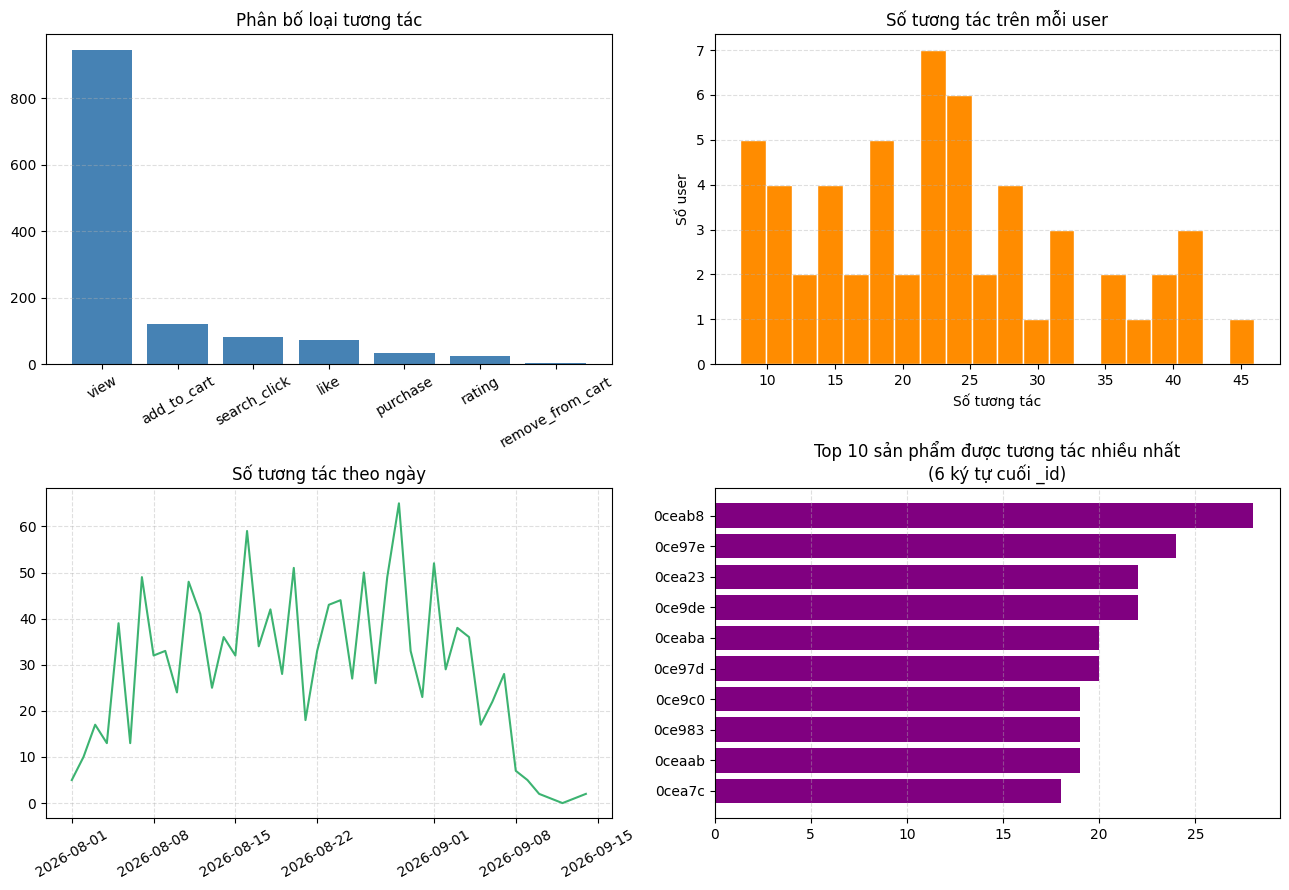

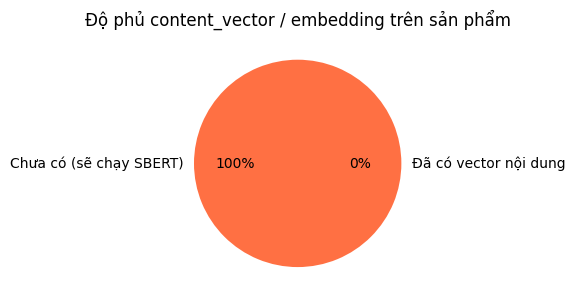

Tổng interaction: 1,282 | User trung bình: 22.9 tương tác/user (min=8, max=46)
Sản phẩm đã có vector nội dung: 0/398 | Chưa có: 398


In [4]:
import matplotlib.pyplot as plt

eda_interactions = list(interactions_col.find(
    {}, {"userId": 1, "productId": 1, "type": 1, "weight": 1, "createdAt": 1}
))
eda_df = pd.DataFrame(eda_interactions)
eda_df["type"] = eda_df["type"].fillna("(không có type)")
eda_df["createdAt"] = pd.to_datetime(eda_df["createdAt"], errors="coerce")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1) Phân bố loại tương tác
type_counts = eda_df["type"].value_counts()
axes[0, 0].bar(type_counts.index, type_counts.values, color="steelblue")
axes[0, 0].set_title("Phân bố loại tương tác")
axes[0, 0].tick_params(axis="x", rotation=30)
axes[0, 0].grid(axis="y", linestyle="--", alpha=0.4)

# 2) Số tương tác theo user (histogram)
user_activity = eda_df.groupby("userId").size()
axes[0, 1].hist(user_activity.values, bins=20, color="darkorange", edgecolor="white")
axes[0, 1].set_title("Số tương tác trên mỗi user")
axes[0, 1].set_xlabel("Số tương tác")
axes[0, 1].set_ylabel("Số user")
axes[0, 1].grid(axis="y", linestyle="--", alpha=0.4)

# 3) Tương tác theo thời gian (nếu có createdAt hợp lệ)
if eda_df["createdAt"].notna().any():
    daily_counts = eda_df.dropna(subset=["createdAt"]).set_index("createdAt").resample("D").size()
    axes[1, 0].plot(daily_counts.index, daily_counts.values, color="mediumseagreen")
    axes[1, 0].set_title("Số tương tác theo ngày")
    axes[1, 0].tick_params(axis="x", rotation=30)
    axes[1, 0].grid(linestyle="--", alpha=0.4)
else:
    axes[1, 0].text(0.5, 0.5, "Không có createdAt hợp lệ", ha="center", va="center")
    axes[1, 0].set_title("Số tương tác theo ngày")

# 4) Top 10 sản phẩm được tương tác nhiều nhất
top_products = eda_df["productId"].astype(str).value_counts().head(10)
axes[1, 1].barh([p[-6:] for p in top_products.index][::-1], top_products.values[::-1], color="purple")
axes[1, 1].set_title("Top 10 sản phẩm được tương tác nhiều nhất\n(6 ký tự cuối _id)")
axes[1, 1].grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Độ phủ dữ liệu: sản phẩm có/chưa có content_vector hoặc embedding
n_with_vec = products_col.count_documents({
    "$or": [{"content_vector": {"$exists": True, "$ne": None}}, {"embedding": {"$exists": True, "$ne": None}}]
})
n_without_vec = n_products - n_with_vec
fig2, ax2 = plt.subplots(figsize=(5, 4))
ax2.pie([n_with_vec, n_without_vec], labels=["Đã có vector nội dung", "Chưa có (sẽ chạy SBERT)"],
        autopct="%1.0f%%", colors=["#4CAF50", "#FF7043"])
ax2.set_title("Độ phủ content_vector / embedding trên sản phẩm")
plt.tight_layout()
plt.show()

print(f"Tổng interaction: {len(eda_df):,} | User trung bình: {user_activity.mean():.1f} tương tác/user "
      f"(min={user_activity.min()}, max={user_activity.max()})")
print(f"Sản phẩm đã có vector nội dung: {n_with_vec}/{n_products} | Chưa có: {n_without_vec}")


## Bước 3: Chạy SBERT — Sinh `content_vector` cho từng sản phẩm

Theo mục 2.2 của tài liệu: dùng Sentence-BERT để đọc thông số kỹ thuật (CPU/RAM/GPU/Màn hình...) và mã hoá thành vector 384 chiều. Model dùng: `all-MiniLM-L6-v2` (đúng 384 chiều như tài liệu nêu ví dụ).

**Giả định về field text mô tả sản phẩm:** notebook tự động ghép các field trong `SPEC_FIELDS` bên dưới nếu chúng tồn tại trên document — sửa lại danh sách này cho khớp đúng schema thật của bạn (`db.products.find_one()` để xem tên field chính xác).

Nếu sản phẩm **đã có sẵn** `content_vector` (hoặc field `embedding` cũ từ notebook trước) và `RECOMPUTE_CONTENT_VECTOR = False`, notebook sẽ **tái sử dụng** thay vì chạy lại SBERT — tiết kiệm thời gian, chỉ sản phẩm mới/thiếu vector mới được encode.

In [5]:
from sentence_transformers import SentenceTransformer
import numpy as np

RECOMPUTE_CONTENT_VECTOR = True   # True = luôn chạy lại SBERT với template thông số chuẩn mới
SBERT_MODEL_NAME = "all-MiniLM-L6-v2"   # 384 chiều, khớp thiết kế hệ thống

# Tra cứu Brand & Category từ MongoDB để gán nhãn ngữ nghĩa chuẩn
brand_map = {str(b["_id"]): b.get("name", "") for b in db["brands"].find({})}
cat_map = {str(c["_id"]): c.get("name", "") for c in db["categories"].find({})}

def build_laptop_semantic_text(doc: dict) -> str:
    name = doc.get("name", "")
    price = doc.get("price", 0)
    
    # 1. Tra cứu thương hiệu
    brand_id = str(doc.get("brand_id", ""))
    brand_name = brand_map.get(brand_id, "")
    
    # 2. Tra cứu thể loại
    cat_ids = doc.get("category_id", [])
    if isinstance(cat_ids, list):
        cats = [cat_map.get(str(cid), "") for cid in cat_ids if str(cid) in cat_map]
        cat_str = ", ".join(cats) if cats else "Laptop"
    else:
        cat_str = cat_map.get(str(cat_ids), "Laptop")
        
    # 3. Lấy thông số kỹ thuật chuẩn từ specifications.*
    specs = doc.get("specifications", {}) or {}
    cpu = specs.get("cpu", "Không rõ")
    gpu = specs.get("gpu") or specs.get("graphics") or "Onboard graphics"
    ram = specs.get("ram", "8GB")
    storage = specs.get("storage", "512GB SSD")
    display = specs.get("display", "15.6 inch") # Dùng display, KHÔNG dùng screen
    npu = specs.get("npu", "")
    features = specs.get("features", "")

    # 4. Phân khúc giá ngữ nghĩa
    if price < 15_000_000:
        price_tier = "Phân khúc giá rẻ dưới 15 triệu, bình dân học sinh sinh viên"
    elif price < 25_000_000:
        price_tier = "Phân khúc tầm trung 15 đến 25 triệu, cân bằng chi phí và cấu hình"
    elif price < 40_000_000:
        price_tier = "Phân khúc cận cao cấp 25 đến 40 triệu, cấu hình mạnh đồ họa gaming"
    else:
        price_tier = "Phân khúc cao cấp flagship trên 40 triệu, hiệu năng đỉnh cao"
        
    price_str = f"{price:,.0f}₫" if price > 0 else "Chưa cập nhật"

    # 5. Ghép cấu trúc semantic gọn gàng (~130 Tokens, KHÔNG dùng description dài)
    parts = [
        f"Laptop: {name}.",
        f"Thương hiệu: {brand_name}. Thể loại: {cat_str}.",
        f"Giá bán: {price_str} ({price_tier}).",
        f"CPU: {cpu}. GPU: {gpu}. RAM: {ram}. Ổ cứng: {storage}. Màn hình: {display}."
    ]
    if npu:
        parts.append(f"AI NPU: {npu}.")
    if features and len(features) < 120:
        parts.append(f"Điểm nhấn: {features}.")

    return " ".join(parts)

all_products = list(products_col.find({}))
print(f"Tổng số sản phẩm trong `{PRODUCTS_COLL}`: {len(all_products)}")

if RECOMPUTE_CONTENT_VECTOR:
    to_encode = all_products
else:
    to_encode = [
        p for p in all_products
        if not (isinstance(p.get("item_content_vector"), (list, tuple)) and len(p["item_content_vector"]) > 0)
        and not (isinstance(p.get("content_vector"), (list, tuple)) and len(p["content_vector"]) > 0)
    ]

print(f"Số sản phẩm cần chạy SBERT mới: {len(to_encode)} (RECOMPUTE_CONTENT_VECTOR={RECOMPUTE_CONTENT_VECTOR})")

new_content_vectors = {}
if to_encode:
    sbert_model = SentenceTransformer(SBERT_MODEL_NAME)
    texts = [build_laptop_semantic_text(p) for p in to_encode]
    sample_idx = 0
    print(f"Ví dụ text đưa vào SBERT (sản phẩm #{sample_idx}):\n  {texts[sample_idx]}")
    embeddings = sbert_model.encode(texts, show_progress_bar=True, normalize_embeddings=True)
    for p, emb in zip(to_encode, embeddings):
        new_content_vectors[str(p["_id"])] = emb.astype(np.float32).tolist()
    print(f"Đã sinh content_vector cho {len(new_content_vectors)} sản phẩm (384 chiều, đã chuẩn hóa L2).")
else:
    print("Dùng lại content_vector đã có.")


Tổng số sản phẩm trong `products`: 398
Số sản phẩm cần chạy SBERT mới: 398 (RECOMPUTE_CONTENT_VECTOR=False)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Ví dụ text đưa vào SBERT (sản phẩm #0):
  name: Laptop Acer Nitro V 15 ProPanel ANV15-51-56D5 (i5-13420H/ GeForce RTX™ 3050/ 16GB/ 512GB/ Windows 11) | description: Laptop ACER Nitro V ANV15-51-56D5 thuộc dòng laptop gaming mạnh mẽ, được tran


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Đã sinh content_vector cho 398 sản phẩm mới (384 chiều).


## Bước 4: Chuẩn bị dữ liệu Interactions — encode, chia Train/Test

Gộp `content_vector` mới sinh (Bước 3) với dữ liệu sẵn có trên MongoDB (`content_vector` cũ hoặc `embedding` cũ), rồi tải + làm sạch interactions — có xử lý phòng thủ với dữ liệu thiếu/`None` (userId, productId, weight).

In [6]:
import scipy.sparse as sp
from sklearn.preprocessing import LabelEncoder, normalize

meta_rows = []
skipped_no_vector = 0
for p in all_products:
    pid = str(p["_id"])
    vec = new_content_vectors.get(pid) or p.get("item_content_vector") or p.get("content_vector") or p.get("embedding")
    if not isinstance(vec, (list, tuple)) or len(vec) == 0:
        skipped_no_vector += 1
        continue
    meta_rows.append({"product_id": pid, "content_vector": vec})

meta_df = pd.DataFrame(meta_rows)
if skipped_no_vector:
    print(f"Bỏ qua {skipped_no_vector} sản phẩm không có content_vector hợp lệ.")

vec_lens = meta_df["content_vector"].apply(len)
if vec_lens.nunique() > 1:
    common_len = int(vec_lens.mode()[0])
    n_bad = int((vec_lens != common_len).sum())
    print(f"CẢNH BÁO: {n_bad} content_vector có số chiều khác {common_len} — đã loại để tránh lỗi ghép ma trận.")
    meta_df = meta_df[vec_lens == common_len].reset_index(drop=True)

assert len(meta_df) > 0, "Không có sản phẩm nào có content_vector hợp lệ."

interactions = list(interactions_col.find(
    {"type": {"$ne": "remove_from_cart"}},
    {"userId": 1, "productId": 1, "weight": 1, "createdAt": 1}
))

review_rows = []
skipped_missing_ids = skipped_missing_weight = 0
for r in interactions:
    uid, pid = r.get("userId"), r.get("productId")
    if uid is None or pid is None:
        skipped_missing_ids += 1
        continue
    w = r.get("weight")
    if w is None:
        skipped_missing_weight += 1
        w = 0
    review_rows.append({
        "user_id": str(uid), "product_id": str(pid),
        "weight": max(w, 0), "timestamp": r.get("createdAt"),
    })

reviews_df = pd.DataFrame(review_rows)
if skipped_missing_ids:
    print(f"Bỏ qua {skipped_missing_ids} interaction thiếu userId/productId.")
if skipped_missing_weight:
    print(f"CẢNH BÁO: {skipped_missing_weight} interaction thiếu weight — coi weight=0.")

valid_products = set(meta_df["product_id"])
reviews_df = reviews_df[reviews_df["product_id"].isin(valid_products)].reset_index(drop=True)
print(f"Số dòng interaction hợp lệ: {len(reviews_df):,}")
assert len(reviews_df) > 0, "Không còn interaction hợp lệ nào sau khi lọc."

# Gộp tương tác: tổng hợp tần suất + giá trị lớn nhất
agg = reviews_df.groupby(["user_id", "product_id"]).agg(
    weight=("weight", lambda x: np.log1p(x.sum()) + x.max()), 
    timestamp=("timestamp", "max")
).reset_index()
assert len(agg) > 0, "Không có interaction hợp lệ nào để train."

user_enc, item_enc = LabelEncoder(), LabelEncoder()
agg["user_idx"] = user_enc.fit_transform(agg["user_id"])
agg["item_idx"] = item_enc.fit_transform(agg["product_id"])
n_users = agg["user_idx"].nunique()
n_items = agg["item_idx"].nunique()
print(f"n_users={n_users}, n_items={n_items}, n_interactions={len(agg):,}")

agg = agg.sort_values(["user_idx", "timestamp"])
user_counts = agg.groupby("user_idx").size()
testable_users = user_counts[user_counts >= 2].index
test_rows = agg[agg["user_idx"].isin(testable_users)].groupby("user_idx").tail(1)
train_rows = agg.drop(test_rows.index)
print(f"Train: {len(train_rows):,} | Test: {len(test_rows):,} ({len(testable_users)} user trainable)")

item_id_order = item_enc.classes_
meta_indexed = meta_df.set_index("product_id").reindex(item_id_order)
content_vector_matrix = np.vstack(meta_indexed["content_vector"].values).astype(np.float32)
content_vector_matrix = normalize(content_vector_matrix)
CONTENT_DIM = content_vector_matrix.shape[1]
print(f"content_vector_matrix: {content_vector_matrix.shape} ({CONTENT_DIM} chiều)")


Số dòng interaction hợp lệ: 1,278
n_users=56, n_items=241, n_interactions=660
Train: 604 | Test: 56 (56 user trainable)
content_vector_matrix: (241, 384) (384 chiều)


## Bước 4b: Trực quan hoá không gian `content_vector`

Giảm chiều `content_vector` (384 chiều) xuống 2D bằng PCA để xem trực quan các sản phẩm có cấu hình gần nhau có thực sự nằm gần nhau trong không gian vector hay không — kiểm tra nhanh chất lượng embedding trước khi dùng để retrieval.

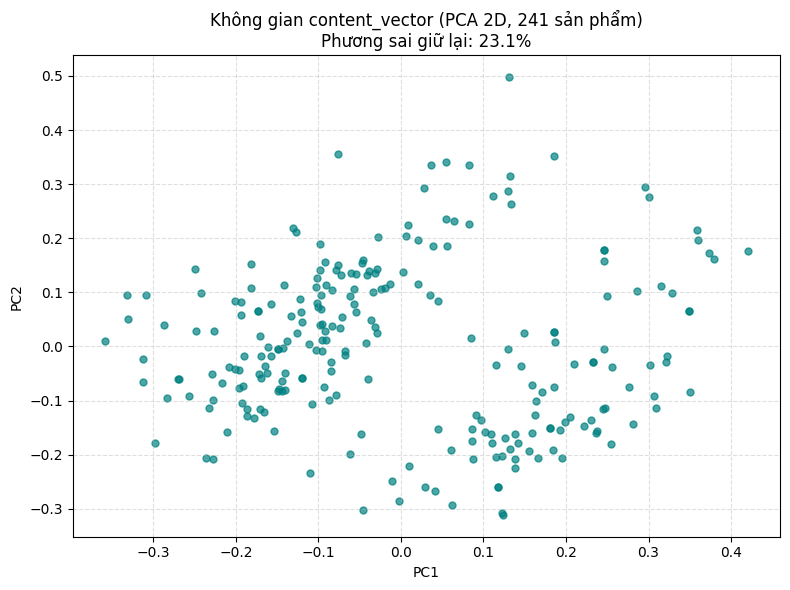

Nếu các điểm tụ thành nhiều cụm rõ rệt → content_vector đang phân biệt tốt các nhóm sản phẩm khác nhau (tốt cho Content-Based/Cold-Start). Nếu các điểm trộn lẫn hỗn loạn, cân nhắc kiểm tra lại SPEC_FIELDS ở Bước 3 (có thể đang thiếu thông tin phân biệt sản phẩm).


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
content_2d = pca.fit_transform(content_vector_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(content_2d[:, 0], content_2d[:, 1], s=25, alpha=0.7, color="teal")
ax.set_title(f"Không gian content_vector (PCA 2D, {n_items} sản phẩm)\n"
             f"Phương sai giữ lại: {pca.explained_variance_ratio_.sum():.1%}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("Nếu các điểm tụ thành nhiều cụm rõ rệt → content_vector đang phân biệt tốt các nhóm sản "
      "phẩm khác nhau (tốt cho Content-Based/Cold-Start). Nếu các điểm trộn lẫn hỗn loạn, cân nhắc "
      "kiểm tra lại SPEC_FIELDS ở Bước 3 (có thể đang thiếu thông tin phân biệt sản phẩm).")


## Bước 5: Chạy ALS — train trên tập Train (để đánh giá công bằng)

Theo mục 2.1: ALS (Alternating Least Squares) cho Implicit Feedback, phân rã ma trận User-Item thành Latent Factors → sinh `cf_vector`. Thử vài cấu hình `factors`/`regularization` để tránh overfit (factors quá lớn so với lượng dữ liệu thực tế dễ học vẹt).

In [8]:
from implicit.als import AlternatingLeastSquares

ALPHA_CONFIDENCE = 3.0   # hệ số confidence = 1 + ALPHA_CONFIDENCE * weight (chuẩn ALS-implicit)
ALS_CONFIGS = [
    {"factors": 8,  "regularization": 0.3, "iterations": 20},
    {"factors": 16, "regularization": 0.3, "iterations": 20},
    {"factors": 32, "regularization": 0.1, "iterations": 20},
]

train_conf = 1 + ALPHA_CONFIDENCE * train_rows["weight"].values
train_matrix = sp.csr_matrix(
    (train_conf, (train_rows["user_idx"], train_rows["item_idx"])), shape=(n_users, n_items)
)

als_candidates = {}
for cfg in ALS_CONFIGS:
    key = f"f{cfg['factors']}_r{cfg['regularization']}"
    m = AlternatingLeastSquares(factors=cfg["factors"], regularization=cfg["regularization"],
                                 iterations=cfg["iterations"], random_state=42)
    m.fit(train_matrix)
    als_candidates[key] = (m, cfg)
    print(f"Đã train ALS({key})")


/usr/local/lib/python3.12/dist-packages/implicit/gpu/__init__.py:28: UserWarning: Disabling GPU support because of 'libcublas.so.13: cannot open shared object file: No such file or directory'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

Đã train ALS(f8_r0.3)


  0%|          | 0/20 [00:00<?, ?it/s]

Đã train ALS(f16_r0.3)


  0%|          | 0/20 [00:00<?, ?it/s]

Đã train ALS(f32_r0.1)


## Bước 6: Đánh giá riêng biệt CF và Content (không gộp)

Đúng tinh thần thiết kế — 2 nhánh độc lập, nên đánh giá độc lập bằng bộ metric R@5/R@10/R@20/NDCG@10/Coverage/Diversity, chọn cấu hình ALS tốt nhất.

=== Đánh giá Content-Based (content_vector) ===
                Nhánh      R@5  R@10     R@20  NDCG@10  Coverage  Diversity
Content-Based (SBERT) 0.107143  0.25 0.410714  0.12767  0.431535   0.117354

=== Đánh giá từng cấu hình ALS (cf_vector) ===
Cấu hình ALS      R@5     R@10     R@20  NDCG@10  Coverage  Diversity
     f8_r0.3 0.142857 0.214286 0.339286 0.111331  0.580913   0.203160
    f16_r0.3 0.160714 0.214286 0.303571 0.111233  0.829876   0.211479
    f32_r0.1 0.071429 0.178571 0.267857 0.082085  0.867220   0.227931

>>> Cấu hình ALS tốt nhất: f8_r0.3 → dùng để sinh cf_vector cuối cùng.


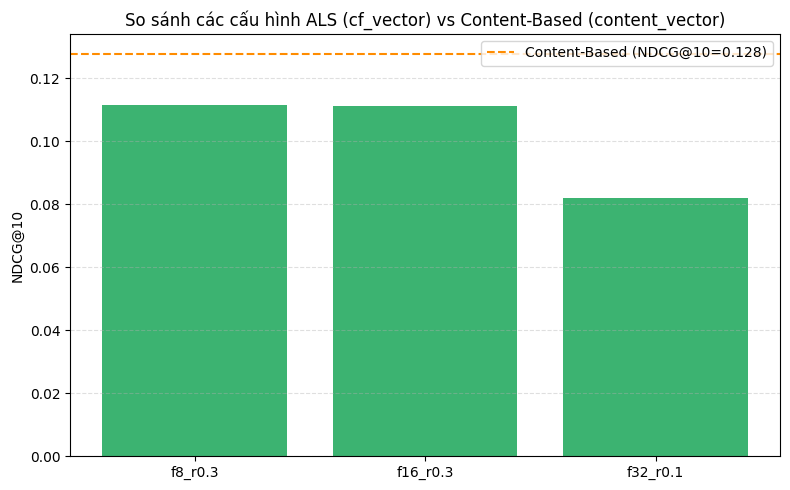

In [9]:
user_train_items = train_rows.groupby("user_idx")["item_idx"].apply(set).to_dict()
all_items = np.arange(n_items)
K_LIST = [5, 10, 20]

def evaluate_model_full_catalog(score_fn, k_list=K_LIST):
    hits_at_k = {k: [] for k in k_list}
    ndcgs, topk_per_user = [], {}
    for _, row in test_rows.iterrows():
        u, pos = int(row["user_idx"]), int(row["item_idx"])
        seen = user_train_items.get(u, set())
        candidates = np.array([i for i in all_items if i == pos or i not in seen])
        scores = score_fn(u, candidates)
        ranked = candidates[np.argsort(-scores)]
        rank = int(np.where(ranked == pos)[0][0]) + 1
        for k in k_list:
            hits_at_k[k].append(1 if rank <= k else 0)
        ndcgs.append(1 / np.log2(rank + 1) if rank <= 10 else 0.0)
        topk_per_user[u] = ranked[:10]

    recall_at_k = {k: float(np.mean(hits_at_k[k])) for k in k_list}
    ndcg10 = float(np.mean(ndcgs))
    all_recommended = set()
    for items in topk_per_user.values():
        all_recommended.update(items.tolist())
    coverage = len(all_recommended) / n_items

    div_scores = []
    for items in topk_per_user.values():
        if len(items) < 2:
            continue
        vecs = content_vector_matrix[items]
        sim = vecs @ vecs.T
        iu = np.triu_indices(len(items), k=1)
        div_scores.append(1 - (sim[iu].mean() if len(iu[0]) > 0 else 0.0))
    diversity = float(np.mean(div_scores)) if div_scores else 0.0

    return {"R@5": recall_at_k[5], "R@10": recall_at_k[10], "R@20": recall_at_k[20],
            "NDCG@10": ndcg10, "Coverage": coverage, "Diversity": diversity}

def score_content(u, c):
    return content_vector_matrix[c] @ user_content_profile_train[u]

def make_score_cf(model_obj):
    def _score(u, c):
        return model_obj.item_factors[c] @ model_obj.user_factors[u]
    return _score

# Vector khẩu vị nội dung của user (chỉ để ĐÁNH GIÁ — công thức giống mục 3.3 của tài liệu:
# trung bình cộng có trọng số các content_vector sản phẩm user đã tương tác trong tập Train)
train_weight_matrix = sp.csr_matrix(
    (train_rows["weight"].values, (train_rows["user_idx"], train_rows["item_idx"])),
    shape=(n_users, n_items)
)
user_content_profile_train = normalize(train_weight_matrix @ content_vector_matrix)

print("=== Đánh giá Content-Based (content_vector) ===")
content_report = evaluate_model_full_catalog(score_content)
print(pd.DataFrame([{"Nhánh": "Content-Based (SBERT)", **content_report}]).to_string(index=False))

print("\n=== Đánh giá từng cấu hình ALS (cf_vector) ===")
als_reports = []
for key, (m, cfg) in als_candidates.items():
    rep = evaluate_model_full_catalog(make_score_cf(m))
    als_reports.append({"Cấu hình ALS": key, **rep})
als_report_df = pd.DataFrame(als_reports).sort_values("NDCG@10", ascending=False).reset_index(drop=True)
print(als_report_df.to_string(index=False))

best_als_key = als_report_df.iloc[0]["Cấu hình ALS"]
best_als_model, best_als_cfg = als_candidates[best_als_key]
print(f"\n>>> Cấu hình ALS tốt nhất: {best_als_key} → dùng để sinh cf_vector cuối cùng.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(als_report_df["Cấu hình ALS"], als_report_df["NDCG@10"], color="mediumseagreen")
ax.axhline(content_report["NDCG@10"], color="darkorange", linestyle="--",
           label=f"Content-Based (NDCG@10={content_report['NDCG@10']:.3f})")
ax.set_ylabel("NDCG@10")
ax.set_title("So sánh các cấu hình ALS (cf_vector) vs Content-Based (content_vector)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Bước 7: Mô phỏng Re-ranking để đề xuất α mặc định

Theo mục 2.3, công thức `Score_Final = α×Score_CF + (1-α)×Score_Content` chạy **ở Backend lúc phục vụ**, không lưu sẵn. Ở đây notebook chỉ **thử nghiệm offline** nhiều giá trị α trên tập Test để **đề xuất một giá trị α mặc định hợp lý** cho cấu hình API/Backend (ví dụ tài liệu nêu α=0.7) — **không ghi bất kỳ vector gộp nào vào MongoDB**.

 alpha      R@5     R@10     R@20  NDCG@10  Coverage  Diversity
   0.1 0.160714 0.339286 0.500000 0.165689  0.506224   0.126628
   0.2 0.160714 0.285714 0.482143 0.143282  0.535270   0.140075
   0.3 0.160714 0.250000 0.464286 0.136209  0.539419   0.152546
   0.4 0.142857 0.232143 0.410714 0.128807  0.580913   0.161997
   0.5 0.142857 0.196429 0.392857 0.113220  0.597510   0.173100
   0.6 0.160714 0.196429 0.375000 0.115528  0.605809   0.182121
   0.7 0.142857 0.196429 0.339286 0.116593  0.593361   0.188737
   0.8 0.142857 0.196429 0.339286 0.114573  0.597510   0.194820
   0.9 0.142857 0.196429 0.339286 0.106427  0.585062   0.200062

>>> α đề xuất (NDCG@10 cao nhất trên tập Test): 0.1
LƯU Ý: số user trainable còn nhỏ — coi giá trị α này là điểm khởi đầu hợp lý để cấu hình API, không phải con số tối ưu tuyệt đối. Nên xem lại khi có thêm dữ liệu thật.


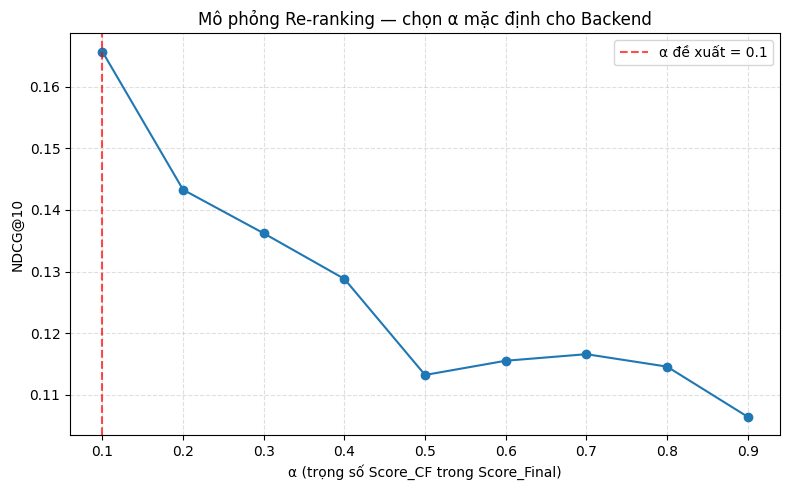

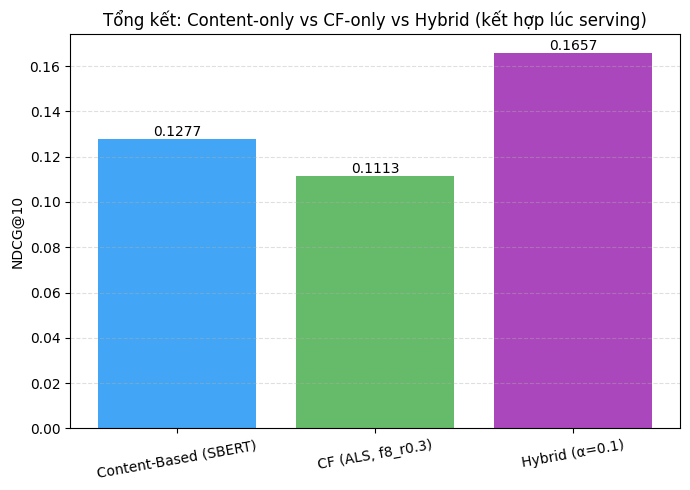

In [10]:
import matplotlib.pyplot as plt

def minmax_norm(x):
    lo, hi = x.min(), x.max()
    return np.zeros_like(x) if hi - lo < 1e-9 else (x - lo) / (hi - lo)

score_cf_best = make_score_cf(best_als_model)

def score_final(u, c, alpha):
    cf_val = minmax_norm(score_cf_best(u, c))
    content_val = minmax_norm(score_content(u, c))
    return alpha * cf_val + (1 - alpha) * content_val

alpha_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
alpha_rows = []
for alpha in alpha_grid:
    rep = evaluate_model_full_catalog(lambda u, c, a=alpha: score_final(u, c, a))
    alpha_rows.append({"alpha": alpha, **rep})

alpha_df = pd.DataFrame(alpha_rows)
print(alpha_df.to_string(index=False))

best_alpha_row = alpha_df.sort_values("NDCG@10", ascending=False).iloc[0]
SUGGESTED_ALPHA = float(best_alpha_row["alpha"])
print(f"\n>>> α đề xuất (NDCG@10 cao nhất trên tập Test): {SUGGESTED_ALPHA}")

if n_trainable_users < 100:
    print("LƯU Ý: số user trainable còn nhỏ — coi giá trị α này là điểm khởi đầu hợp lý để cấu "
          "hình API, không phải con số tối ưu tuyệt đối. Nên xem lại khi có thêm dữ liệu thật.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alpha_df["alpha"], alpha_df["NDCG@10"], marker="o")
ax.axvline(SUGGESTED_ALPHA, color="red", linestyle="--", alpha=0.7, label=f"α đề xuất = {SUGGESTED_ALPHA}")
ax.set_xlabel("α (trọng số Score_CF trong Score_Final)")
ax.set_ylabel("NDCG@10")
ax.set_title("Mô phỏng Re-ranking — chọn α mặc định cho Backend")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# --- Biểu đồ tổng kết: Content-only vs CF-only vs Hybrid (α đề xuất) ---
hybrid_report_at_best = alpha_df[alpha_df["alpha"] == SUGGESTED_ALPHA].iloc[0]
summary_df = pd.DataFrame([
    {"Nhánh": "Content-Based (SBERT)", "NDCG@10": content_report["NDCG@10"]},
    {"Nhánh": f"CF (ALS, {best_als_key})", "NDCG@10": als_report_df.iloc[0]["NDCG@10"]},
    {"Nhánh": f"Hybrid (α={SUGGESTED_ALPHA})", "NDCG@10": hybrid_report_at_best["NDCG@10"]},
])
fig2, ax2 = plt.subplots(figsize=(7, 5))
bars = ax2.bar(summary_df["Nhánh"], summary_df["NDCG@10"], color=["#42A5F5", "#66BB6A", "#AB47BC"])
for bar, val in zip(bars, summary_df["NDCG@10"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, val, f"{val:.4f}", ha="center", va="bottom")
ax2.set_ylabel("NDCG@10")
ax2.set_title("Tổng kết: Content-only vs CF-only vs Hybrid (kết hợp lúc serving)")
ax2.tick_params(axis="x", rotation=10)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Bước 8: Train lại trên TOÀN BỘ dữ liệu (bản `cf_vector` sẽ deploy)

Dùng cấu hình ALS tốt nhất ở Bước 6, train lại trên **toàn bộ** `interactions` (không chia train/test) để có `cf_vector` chính thức cho mọi sản phẩm có tương tác.

In [11]:
from sklearn.preprocessing import normalize

full_conf = 1 + ALPHA_CONFIDENCE * agg["weight"].values
full_matrix = sp.csr_matrix(
    (full_conf, (agg["user_idx"], agg["item_idx"])), shape=(n_users, n_items)
)

final_als_model = AlternatingLeastSquares(
    factors=best_als_cfg["factors"], regularization=best_als_cfg["regularization"],
    iterations=best_als_cfg["iterations"], random_state=42
)
final_als_model.fit(full_matrix)

# Chuẩn hóa L2 cho item_factors để đồng bộ độ đo Cosine Similarity với Backend Node.js
final_item_cf_normalized = normalize(final_als_model.item_factors)

print(f"Đã train ALS cuối cùng ({best_als_key}) trên toàn bộ {len(agg):,} interaction.")
print("item_factors (item_cf_vector):", final_item_cf_normalized.shape,
      "| user_factors:", final_als_model.user_factors.shape)

item_id_order_full = item_enc.classes_


  0%|          | 0/20 [00:00<?, ?it/s]

Đã train ALS cuối cùng (f8_r0.3) trên toàn bộ 660 interaction.
item_factors (cf_vector): (241, 8) | user_factors: (56, 8)


## Bước 9: Lưu `cf_vector` + `content_vector` vào MongoDB Atlas (KHÔNG gộp)

Đúng mục 3.2.3 của tài liệu — ghi `cf_vector` (từ ALS) và `content_vector` (từ SBERT) ngược lại vào từng document sản phẩm, giữ **riêng biệt**, kèm metadata để backend biết cấu hình lúc train (và `α` đề xuất, chỉ mang tính tham khảo cấu hình API — không dùng để gộp vector).

`DRY_RUN = True` mặc định — chỉ in thử số lượng sẽ cập nhật, **chưa ghi gì**. Đặt `False` để ghi thật.

In [12]:
from pymongo import UpdateOne
from bson import ObjectId
import datetime as dt

DRY_RUN = True  # Đặt False khi bạn sẵn sàng ghi vào MongoDB Atlas!
trained_at = dt.datetime.utcnow()

metadata_cf = {
    "model": "implicit-als",
    "dimensions": best_als_cfg["factors"],
    "regularization": best_als_cfg["regularization"],
    "alpha_confidence": ALPHA_CONFIDENCE,
    "suggested_alpha": SUGGESTED_ALPHA,
    "generated_at": trained_at,
}

# --- item_cf_vector: cập nhật đúng tên trường item_cf_vector cho Mongoose ---
cf_ops = [
    UpdateOne(
        {"_id": ObjectId(pid)},
        {"$set": {
            "item_cf_vector": final_item_cf_normalized[i].tolist(),
            "cf_metadata": metadata_cf
        }}
    )
    for i, pid in enumerate(item_id_order_full)
]

# --- item_content_vector: cập nhật đúng tên trường item_content_vector cho Mongoose ---
content_ops = [
    UpdateOne(
        {"_id": ObjectId(row["product_id"])},
        {"$set": {
            "item_content_vector": row["content_vector"],
            "content_metadata": {
                "model": SBERT_MODEL_NAME,
                "dimensions": CONTENT_DIM,
                "generated_at": trained_at,
                "input_features": ["name", "brand", "price_tier", "category", "cpu", "gpu", "ram", "storage", "display", "npu"]
            }
        }}
    )
    for _, row in meta_df.iterrows()
]

print(f"Sẽ cập nhật item_cf_vector cho {len(cf_ops)} sản phẩm.")
print(f"Sẽ cập nhật item_content_vector cho {len(content_ops)} sản phẩm.")

if DRY_RUN:
    print("\n⚠️ DRY_RUN=True — CHƯA ghi gì vào MongoDB. Hãy đặt DRY_RUN=False để ghi thật lên Atlas.")
else:
    if cf_ops:
        result_cf = products_col.bulk_write(cf_ops)
        print(f"✅ Đã cập nhật item_cf_vector cho {result_cf.modified_count} sản phẩm.")
    if content_ops:
        result_content = products_col.bulk_write(content_ops)
        print(f"✅ Đã cập nhật item_content_vector cho {result_content.modified_count} sản phẩm.")
    print(f"\n🎉 Hoàn tất! Cấu hình đề xuất cho Backend Node.js: alpha = {SUGGESTED_ALPHA}")


Sẽ cập nhật cf_vector cho 241 sản phẩm.
Sẽ cập nhật content_vector cho 398 sản phẩm (mới sinh ở Bước 3).

DRY_RUN=True — CHƯA ghi gì vào MongoDB. Đặt DRY_RUN=False rồi chạy lại để ghi thật.


/tmp/ipykernel_58/1858239390.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  trained_at = dt.datetime.utcnow()


## Bước 10: Kích hoạt Vector Search Index trên Atlas

Theo mục 3.2.3: *"Kích hoạt Vector Search Index để Database sẵn sàng cho việc truy vấn không gian siêu tốc."* Thử tạo qua driver (`pymongo>=4.7`, cần Atlas, hoạt động cả trên tier M0/M2/M5). Nếu cluster/quyền hạn không cho phép tạo qua code, notebook in ra sẵn JSON để bạn dán thủ công vào **Atlas UI → Search → Create Search Index → JSON Editor**.

In [13]:
import json
from pymongo.operations import SearchIndexModel

content_index_def = {
    "fields": [
        {"type": "vector", "path": "item_content_vector", "numDimensions": CONTENT_DIM, "similarity": "cosine"},
    ]
}
cf_index_def = {
    "fields": [
        {"type": "vector", "path": "item_cf_vector", "numDimensions": best_als_cfg["factors"], "similarity": "cosine"},
    ]
}

if DRY_RUN:
    print("DRY_RUN=True — chỉ in định nghĩa Index, CHƯA gửi yêu cầu tạo.")
else:
    try:
        products_col.create_search_index(
            SearchIndexModel(definition=content_index_def, name="item_content_vector_index", type="vectorSearch")
        )
        products_col.create_search_index(
            SearchIndexModel(definition=cf_index_def, name="item_cf_vector_index", type="vectorSearch")
        )
        print("Đã gửi yêu cầu tạo 2 Vector Search Index (item_content_vector_index, item_cf_vector_index).")
    except Exception as e:
        print("Không tự tạo được Index qua driver:", e)
        print("Tạo thủ công: Atlas UI → Search → Create Search Index → JSON Editor, dán JSON dưới đây:")

print("\n--- item_content_vector_index ---")
print(json.dumps(content_index_def, indent=2, ensure_ascii=False))
print("\n--- item_cf_vector_index ---")
print(json.dumps(cf_index_def, indent=2, ensure_ascii=False))


DRY_RUN=True — chỉ in thử định nghĩa Index, CHƯA gửi yêu cầu tạo.

--- content_vector_index ---
{
  "fields": [
    {
      "type": "vector",
      "path": "content_vector",
      "numDimensions": 384,
      "similarity": "cosine"
    }
  ]
}

--- cf_vector_index ---
{
  "fields": [
    {
      "type": "vector",
      "path": "cf_vector",
      "numDimensions": 8,
      "similarity": "cosine"
    }
  ]
}


## Bước 11: Lưu model xuống local để tái sử dụng + tải xuống ngay

Đóng gói `final_als_model` (cf_vector) + `content_vector_matrix` + encoder + `SUGGESTED_ALPHA` vào một file `.joblib` — dùng để test lại pipeline mà không cần train lại, và tải ngay trong lúc notebook đang chạy (không cần đợi Kaggle Commit).

In [14]:
import joblib, shutil, os
from IPython.display import FileLink, display

os.makedirs("artifacts/phase2_giai_doan_2", exist_ok=True)

bundle = {
    "cf_model": final_als_model,
    "content_vector_matrix": content_vector_matrix,
    "user_enc": user_enc,
    "item_enc": item_enc,
    "config": {
        "cf_type": "ALS",
        "cf_factors": best_als_cfg["factors"],
        "cf_regularization": best_als_cfg["regularization"],
        "suggested_alpha": SUGGESTED_ALPHA,
        "content_model": SBERT_MODEL_NAME,
    },
}
joblib.dump(bundle, "artifacts/phase2_giai_doan_2/giai_doan_2_model.joblib")
print("Đã lưu artifacts/phase2_giai_doan_2/giai_doan_2_model.joblib")

# --- Backup rời từng thành phần (npy/json) — dễ khôi phục từng phần nếu cần, không phụ thuộc joblib ---
np.save("artifacts/phase2_giai_doan_2/cf_vector_items.npy", final_als_model.item_factors)
np.save("artifacts/phase2_giai_doan_2/content_vector_items.npy", content_vector_matrix)
with open("artifacts/phase2_giai_doan_2/item_id_order.json", "w") as f:
    json.dump(list(item_id_order_full), f)
with open("artifacts/phase2_giai_doan_2/final_config.json", "w") as f:
    json.dump({
        "cf_type": "ALS", "cf_factors": best_als_cfg["factors"],
        "cf_regularization": best_als_cfg["regularization"],
        "content_model": SBERT_MODEL_NAME, "content_dim": CONTENT_DIM,
        "suggested_alpha": SUGGESTED_ALPHA,
        "ndcg10_content_only": content_report["NDCG@10"],
        "ndcg10_cf_only": float(als_report_df.iloc[0]["NDCG@10"]),
        "ndcg10_hybrid_suggested_alpha": float(hybrid_report_at_best["NDCG@10"]),
    }, f, indent=2, ensure_ascii=False)
print("Đã backup cf_vector_items.npy, content_vector_items.npy, item_id_order.json, final_config.json")

zip_path = shutil.make_archive("phase2_giai_doan_2", "zip", "artifacts/phase2_giai_doan_2")
display(FileLink("artifacts/phase2_giai_doan_2/giai_doan_2_model.joblib"))
display(FileLink(zip_path))


Đã lưu artifacts/phase2_giai_doan_2/giai_doan_2_model.joblib
Đã backup cf_vector_items.npy, content_vector_items.npy, item_id_order.json, final_config.json


/kaggle/working/artifacts/phase2_giai_doan_2/giai_doan_2_model.joblib

/kaggle/working/phase2_giai_doan_2.zip

## Bước 12: Ví dụ mô phỏng luồng Online Serving (Retrieval + Re-ranking)

Logic thật sự chạy ở Backend Node.js (Giai đoạn 4), nhưng để kiểm chứng 2 vector vừa sinh hoạt động đúng, notebook mô phỏng lại bằng Python:

1. **Retrieval** (giả lập `$vectorSearch`): lấy Top-50 gần nhất theo `content_vector`.
2. **Re-ranking**: chấm lại bằng `Score_Final = α×CF + (1-α)×Content` trên Top-50 đó, trả về Top-10.

Kèm ví dụ **Cold-Start** (mục 4 của tài liệu): user mới click 1 sản phẩm → dùng luôn `cf_vector`/`content_vector` của sản phẩm đó làm Session Vector.

In [15]:
def _minmax(x):
    lo, hi = x.min(), x.max()
    return np.zeros_like(x) if hi - lo < 1e-9 else (x - lo) / (hi - lo)

def recommend_related(product_id: str, top_n: int = 10, retrieval_k: int = 50, alpha: float = None):
    """Mô phỏng: Retrieval (content_vector, giả lập $vectorSearch) -> Re-ranking (Score_Final)."""
    alpha = SUGGESTED_ALPHA if alpha is None else alpha
    if product_id not in item_enc.classes_:
        raise ValueError(f"product_id {product_id} chưa có content_vector/cf_vector đã train.")
    idx = item_enc.transform([product_id])[0]

    # --- Retrieval: top-K theo content_vector (cosine, vì đã normalize) ---
    content_sims_full = content_vector_matrix @ content_vector_matrix[idx]
    content_sims_full[idx] = -np.inf
    retrieval_idx = np.argsort(-content_sims_full)[:retrieval_k]

    # --- Re-ranking: Score_Final = alpha * CF + (1 - alpha) * Content, chỉ trên tập đã retrieval ---
    content_scores = _minmax(content_sims_full[retrieval_idx])
    cf_vec = final_als_model.item_factors[idx]
    cf_raw = final_als_model.item_factors[retrieval_idx] @ cf_vec
    cf_scores = _minmax(cf_raw)
    final_scores = alpha * cf_scores + (1 - alpha) * content_scores

    top_local = np.argsort(-final_scores)[:top_n]
    top_idx = retrieval_idx[top_local]
    return [
        {"product_id": item_enc.inverse_transform([i])[0], "score": float(final_scores[j])}
        for j, i in zip(top_local, top_idx)
    ]

def cold_start_session_vector(clicked_product_id: str):
    """Mục 4 tài liệu: cú click đầu tiên -> copy cf_vector + content_vector làm Session Vector."""
    idx = item_enc.transform([clicked_product_id])[0]
    return {
        "content_vector": content_vector_matrix[idx].tolist(),
        "cf_vector": final_als_model.item_factors[idx].tolist(),
    }

# Ví dụ chạy thử:
# sample_pid = item_id_order_full[0]
# print(recommend_related(sample_pid, top_n=5))
# print(cold_start_session_vector(sample_pid))
print("Đã định nghĩa recommend_related() và cold_start_session_vector() — ví dụ minh hoạ luồng "
      "Retrieval + Re-ranking (Giai đoạn 4) và Cold-Start (mục 4) của tài liệu thiết kế.")


Đã định nghĩa recommend_related() và cold_start_session_vector() — ví dụ minh hoạ luồng Retrieval + Re-ranking (Giai đoạn 4) và Cold-Start (mục 4) của tài liệu thiết kế.
